In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("sales_data.csv")
missing_per_column = df.isna().sum()
total_missing = missing_per_column.sum()

print(missing_per_column)
print("Total missing values:", total_missing)


Date                   0
Day                 7947
Month                  0
Year                5493
Customer_Age        5079
Age_Group              0
Customer_Gender        1
Country                1
State                  1
Product_Category       1
Sub_Category           1
Product                1
Order_Quantity      6824
Unit_Cost           7322
Unit_Price          2492
Profit              7585
Cost                7233
Revenue             1974
dtype: int64
Total missing values: 51955


In [3]:
df.shape

(70165, 18)

Number of tuples with specific missing values:
0     36351
1     24257
2      6848
3      1203
4       111
5         8
7      1201
8       176
9         9
13        1
Name: count, dtype: int64


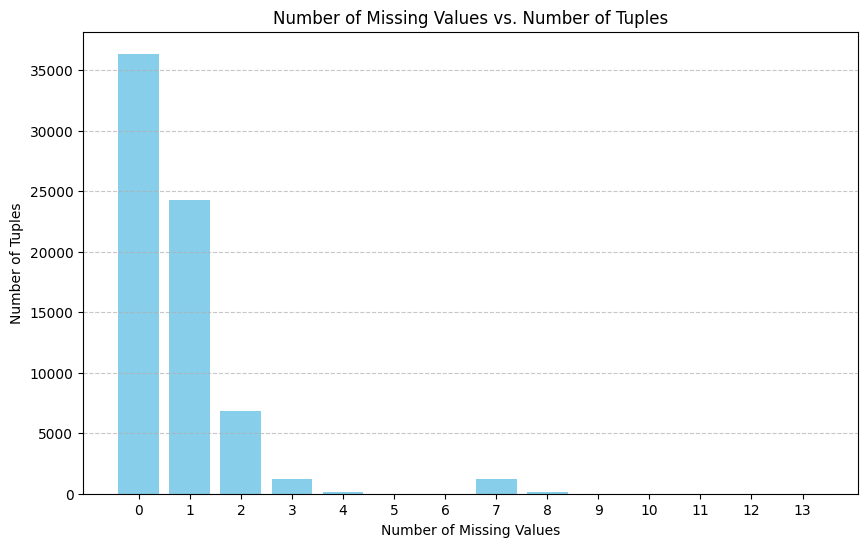

In [5]:
missing_counts = df.isnull().sum(axis=1)

missing_value_distribution = missing_counts.value_counts().sort_index()

print("Number of tuples with specific missing values:")
print(missing_value_distribution)


plt.figure(figsize=(10, 6))
plt.bar(missing_value_distribution.index, missing_value_distribution.values, color='skyblue')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Tuples')
plt.title('Number of Missing Values vs. Number of Tuples')
plt.xticks(range(missing_value_distribution.index.min(), missing_value_distribution.index.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [6]:
threshold = len(df.columns) / 2

tuples_with_high_missing = (missing_counts >= threshold).sum()
print(f"Number of tuples with >=50% of attributes missing: {tuples_with_high_missing}")


df_cleaned = df[missing_counts < threshold]
print(f"After dropping tuples with >=50% missing values, the dataset has {len(df_cleaned)} rows.")


Number of tuples with >=50% of attributes missing: 10
After dropping tuples with >=50% missing values, the dataset has 70155 rows.


In [7]:
df_target_cleaned = df_cleaned.dropna(subset=['Revenue'])
print(f"After dropping tuples with missing 'Revenue' attribute, the dataset has {len(df_target_cleaned)} rows.")

df_target_cleaned.to_csv('sales_data_updated.csv', index=False)
print("Cleaned dataset saved as 'sales_data_updated.csv'.")

After dropping tuples with missing 'Revenue' attribute, the dataset has 68191 rows.
Cleaned dataset saved as 'sales_data_updated.csv'.


In [8]:
# Select only numeric columns for median computation
numeric_columns = df_target_cleaned.select_dtypes(include=['number']).columns

# Compute the median for numeric columns
medians = df_target_cleaned[numeric_columns].median()

# Fill missing values in numeric columns with their respective medians
df_filled_median = df_target_cleaned.copy()
df_filled_median[numeric_columns] = df_filled_median[numeric_columns].fillna(medians)

# Print the results
print("Missing values replaced by the median of their respective attributes.")
print(df_filled_median.head())  # Display the first few rows of the updated dataset

# Verify if there are any missing values remaining
print("\nNumber of missing values in each attribute after replacement:")
print(df_filled_median.isnull().sum())


Missing values replaced by the median of their respective attributes.
         Date   Day     Month    Year  Customer_Age       Age_Group  \
0  2013-11-26  16.0  November  2013.0          19.0     Youth (<25)   
1  2015-11-26  26.0  November  2015.0          19.0     Youth (<25)   
2  2014-03-23  23.0     March  2014.0          49.0  Adults (35-64)   
3  2016-03-23  23.0     March  2016.0          49.0  Adults (35-64)   
5  2016-05-15  15.0       May  2016.0          47.0  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
5               F  Australia   New South Wales      Accessories   Bike Racks   

               Product

In [9]:
df_processed = df_filled_median  # This is the DataFrame after filling missing values with median


# Compute statistics for the processed dataset
processed_stats = df_processed.describe().transpose()
processed_stats['Mode'] = df_processed.mode().iloc[0]

print(processed_stats['mean'], processed_stats['50%'], processed_stats['Mode'],processed_stats['std'])

Day                 15.653620
Year              2014.297752
Customer_Age        35.837765
Order_Quantity      10.751829
Unit_Cost          311.613923
Unit_Price         571.297503
Profit             325.909768
Cost               559.983854
Revenue            939.517326
Name: mean, dtype: float64 Day                 16.0
Year              2014.0
Customer_Age        35.0
Order_Quantity       9.0
Unit_Cost           13.0
Unit_Price          35.0
Profit             167.0
Cost               198.0
Revenue            427.0
Name: 50%, dtype: float64 Day                 16.0
Year              2014.0
Customer_Age        35.0
Order_Quantity       1.0
Unit_Cost           13.0
Unit_Price          35.0
Profit             167.0
Cost               198.0
Revenue           2274.0
Name: Mode, dtype: object Day                  8.318811
Year                 1.290315
Customer_Age        10.425938
Order_Quantity       9.144288
Unit_Cost          577.875367
Unit_Price        1003.181743
Profit             46

In [10]:
# Replace missing values by propagating previous non-missing values
df_filled_propagated = df.fillna(method='ffill')

# Display the first few rows of the filled DataFrame
print("DataFrame after forward filling missing values:")
print(df_filled_propagated.head())

# Check if there are still missing values
missing_values_count = df_filled_propagated.isnull().sum().sum()
print(f"Total number of missing values after forward filling: {missing_values_count}")


DataFrame after forward filling missing values:
         Date   Day     Month    Year  Customer_Age       Age_Group  \
0  2013-11-26   NaN  November  2013.0          19.0     Youth (<25)   
1  2015-11-26  26.0  November  2015.0          19.0     Youth (<25)   
2  2014-03-23  23.0     March  2014.0          49.0  Adults (35-64)   
3  2016-03-23  23.0     March  2016.0          49.0  Adults (35-64)   
4  2014-05-15  23.0       May  2016.0          49.0  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Unit

/tmp/ipython-input-4011180302.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled_propagated = df.fillna(method='ffill')


In [11]:
# Replace missing values by propagating previous non-missing values
df_bfilled_propagated = df.fillna(method='bfill')

# Display the first few rows of the filled DataFrame
print("DataFrame after backward filling missing values:")
print(df_bfilled_propagated.head())

# Check if there are still missing values
missing_values_count2 = df_bfilled_propagated.isnull().sum().sum()
print(f"Total number of missing values after backward filling: {missing_values_count2}")

DataFrame after backward filling missing values:
         Date   Day     Month    Year  Customer_Age       Age_Group  \
0  2013-11-26  26.0  November  2013.0          19.0     Youth (<25)   
1  2015-11-26  26.0  November  2015.0          19.0     Youth (<25)   
2  2014-03-23  23.0     March  2014.0          49.0  Adults (35-64)   
3  2016-03-23  23.0     March  2016.0          49.0  Adults (35-64)   
4  2014-05-15  15.0       May  2016.0          47.0  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Uni

/tmp/ipython-input-2297049942.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfilled_propagated = df.fillna(method='bfill')


In [12]:
# Replace missing values using linear interpolation
df_interpolated = df.interpolate(method='linear', axis=0)

# Display the first few rows of the interpolated DataFrame
print("DataFrame after linear interpolation:")
print(df_interpolated.head())

# Check for remaining missing values
missing_values_count = df_interpolated.isnull().sum().sum()
print(f"Total number of missing values after linear interpolation: {missing_values_count}")


DataFrame after linear interpolation:
         Date   Day     Month    Year  Customer_Age       Age_Group  \
0  2013-11-26   NaN  November  2013.0          19.0     Youth (<25)   
1  2015-11-26  26.0  November  2015.0          19.0     Youth (<25)   
2  2014-03-23  23.0     March  2014.0          49.0  Adults (35-64)   
3  2016-03-23  23.0     March  2016.0          49.0  Adults (35-64)   
4  2014-05-15  19.0       May  2016.0          48.0  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Unit_Cost  Uni

/tmp/ipython-input-1985728227.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df.interpolate(method='linear', axis=0)
